# Hacker News front page — EDA

Dataset: [nicapotato/hacker-news](https://www.kaggle.com/datasets/nicapotato/hacker-news) (`articles.parquet` + daily `snapshots/`).

**Grain:** one row per **story** in the entity table; each scrape adds a snapshot with rank, points, and comment count.

**Objective:** characterize what reaches the HN front page — link domains, submitters, and how engagement (points, comments) relates to rank.


In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from kagglehub import KaggleDatasetAdapter
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "legend.fontsize": 10,
    }
)

DATA_SLUG = "nicapotato/hacker-news"
ARTICLES_FILE = "articles.parquet"
SNAPSHOTS_DIR = "snapshots"
TOP_N_DOMAINS = 8


In [2]:
def load_parquet_file(file_path: str) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(
            kaggle_root.rglob(file_path),
            key=lambda p: p.stat().st_size,
            reverse=True,
        )
        if matches:
            print(f"Kaggle input: {matches[0]}")
            return pd.read_parquet(matches[0])

    local = Path("data") / file_path
    if local.exists():
        print(f"Local: {local.resolve()}")
        return pd.read_parquet(local)

    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATA_SLUG,
        file_path,
    )
    print(f"kagglehub: {DATA_SLUG}/{file_path}")
    return df


def load_snapshots() -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        paths = sorted(kaggle_root.rglob(f"{SNAPSHOTS_DIR}/**/*.parquet"))
        assert paths, f"no snapshot parquet under {kaggle_root}/{SNAPSHOTS_DIR}"
        print(f"Kaggle snapshots: {len(paths)} partition file(s)")
        return pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)

    local_root = Path("data") / SNAPSHOTS_DIR
    if local_root.exists():
        paths = sorted(local_root.rglob("*.parquet"))
        assert paths, f"no parquet under {local_root}"
        print(f"Local snapshots: {len(paths)} partition file(s)")
        return pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)

    root = Path(kagglehub.dataset_download(DATA_SLUG))
    paths = sorted((root / SNAPSHOTS_DIR).rglob("*.parquet"))
    assert paths, f"no snapshot parquet under {root}/{SNAPSHOTS_DIR}"
    print(f"kagglehub snapshots: {len(paths)} partition file(s)")
    return pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)


articles = load_parquet_file(ARTICLES_FILE)
snapshots = load_snapshots()

print("Articles:", articles.shape[0], "rows ×", articles.shape[1], "cols")
print("Snapshots:", snapshots.shape[0], "rows ×", snapshots.shape[1], "cols")

latest_ts = snapshots["scrape_timestamp"].max()
snap_latest = snapshots.loc[snapshots["scrape_timestamp"] == latest_ts].copy()
df = articles.merge(snap_latest, on="article_id", how="inner", validate="1:1")
df = df.sort_values("rank").reset_index(drop=True)

print("Joined (latest scrape):", df.shape[0], "rows ×", df.shape[1], "cols")
print("Scrape timestamp:", latest_ts)
print("First 5 records:")
display(df.head())


Kaggle input: /kaggle/input/datasets/nicapotato/hacker-news/articles.parquet
Kaggle snapshots: 5 partition file(s)
Articles: 1049 rows × 5 cols
Snapshots: 2280 rows × 8 cols
Joined (latest scrape): 895 rows × 12 cols
Scrape timestamp: 2026-05-26 10:00:23.421383+00:00
First 5 records:


,article_id,title,story_url,domain,submitter,scrape_timestamp,year,month,day,rank,points,comment_count
0,48276363,"DynIP – Dynamic DNS with RFC 2136, IPv6, DNSSE...",https://dynip.dev/,dynip.dev,dynip,2026-05-26 10:00:23.421383+00:00,2026,5,26,1,100.0,29.0
1,48272984,Using AI to write better code more slowly,https://nolanlawson.com/2026/05/25/using-ai-to...,nolanlawson.com,signa11,2026-05-26 10:00:23.421383+00:00,2026,5,26,2,645.0,246.0
2,48272670,Taking a walk may lead to more creativity than...,https://www.apa.org/news/press/releases/2014/0...,apa.org,bilsbie,2026-05-26 10:00:23.421383+00:00,2026,5,26,3,297.0,104.0
3,48237012,Use Boring Languages with LLMs,https://jry.io/writing/use-boring-languages-wi...,jry.io,evakhoury,2026-05-26 10:00:23.421383+00:00,2026,5,26,4,47.0,30.0
4,48274711,Earthion: A New Mega Drive-Style Shoot-Em-Up,https://earthiongame.com/,earthiongame.com,MrBuddyCasino,2026-05-26 10:00:23.421383+00:00,2026,5,26,5,68.0,28.0


In [3]:
display(df.sample(min(5, len(df)), random_state=42))
display(df.dtypes.to_frame("dtype"))
display(df[["rank", "points", "comment_count"]].describe().T)

missing = df[["title", "story_url", "rank"]].isna().sum()
print("Missing key fields:\n", missing.to_string())

df["domain_clean"] = df["domain"].fillna("(no domain)")
df["submitter_clean"] = df["submitter"].fillna("(unknown)")
df["rank_tier"] = pd.cut(
    df["rank"],
    bins=[0, 10, 20, 30],
    labels=["Top 10", "11–20", "21–30"],
    include_lowest=True,
)

top_domains = df["domain_clean"].value_counts().head(TOP_N_DOMAINS).index.tolist()
df["domain_top"] = np.where(
    df["domain_clean"].isin(top_domains),
    df["domain_clean"],
    "Other",
)

print(f"{df['article_id'].nunique()} stories; {df['domain_clean'].nunique()} domains; {df['submitter_clean'].nunique()} submitters")


,article_id,title,story_url,domain,submitter,scrape_timestamp,year,month,day,rank,points,comment_count
711,48243096,"Students Create a Self-Balancing, Self-Driving...",https://www.core77.com/posts/144138/Students-C...,core77.com,sizzle,2026-05-26 10:00:23.421383+00:00,2026,5,26,712,18.0,3.0
440,48214188,PopuLoRA: Co-Evolving LLM Populations for Reas...,https://vmax.ai/team/populora-co-evolving-llm-...,vmax.ai,AMavorParker,2026-05-26 10:00:23.421383+00:00,2026,5,26,441,51.0,6.0
525,48172320,Growing Neural Cellular Automata,https://distill.pub/2020/growing-ca/,distill.pub,pulkitsh1234,2026-05-26 10:00:23.421383+00:00,2026,5,26,526,132.0,13.0
722,48221518,Tesla Cybertruck driver arrested after driving...,https://www.bbc.co.uk/news/articles/c072x1kml44o,bbc.co.uk,LaSombra,2026-05-26 10:00:23.421383+00:00,2026,5,26,723,35.0,9.0
39,48267829,Launch HN: Chert (YC P26) – Twilio for iMessage,https://www.trychert.com,trychert.com,garygao,2026-05-26 10:00:23.421383+00:00,2026,5,26,40,57.0,182.0


,dtype
article_id,object
title,object
story_url,object
domain,object
submitter,object
scrape_timestamp,"datetime64[us, UTC]"
year,uint16
month,uint8
day,uint8
rank,uint16


,count,mean,std,min,25%,50%,75%,max
rank,895.0,448.000000,258.508543,1.0,224.5,448.0,671.50,895.0
points,894.0,137.705817,202.126555,3.0,15.0,55.0,172.75,1430.0
comment_count,765.0,90.436601,155.128946,1.0,6.0,26.0,113.00,1948.0


Missing key fields:
 title        0
story_url    0
rank         0
895 stories; 684 domains; 658 submitters


## 1 — Univariate distributions

Front-page stories mix outbound links, `github.com`, blogs, and occasional Ask HN / Show HN posts. Rank, points, and comment counts are right-skewed — a few breakout threads dominate engagement.


/tmp/ipykernel_16/3785096406.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=ax, palette="muted")
/tmp/ipykernel_16/3785096406.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=ax, palette="muted")
/tmp/ipykernel_16/3785096406.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=ax, palette="muted")


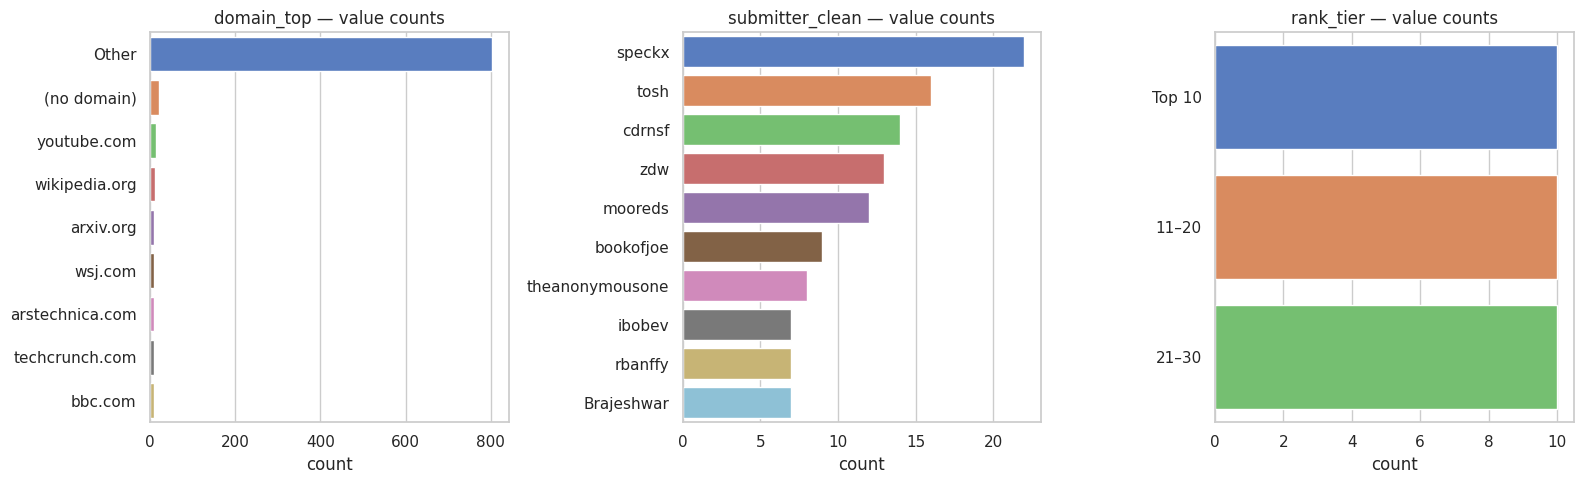

Top domains:
domain_clean
(no domain)        21
youtube.com        14
wikipedia.org      11
arxiv.org          10
wsj.com            10
arstechnica.com     9
techcrunch.com      9
bbc.com             9
theguardian.com     8
nytimes.com         7

Top submitters:
submitter_clean
speckx             22
tosh               16
cdrnsf             14
zdw                13
mooreds            12
bookofjoe           9
theanonymousone     8
ibobev              7
rbanffy             7
Brajeshwar          7


In [4]:
cat_cols = ["domain_top", "submitter_clean", "rank_tier"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index.tolist()
    if col == "submitter_clean":
        order = df[col].value_counts().head(10).index.tolist()
    sns.countplot(data=df, y=col, order=order, ax=ax, palette="muted")
    ax.set_title(f"{col} — value counts")
    ax.set_xlabel("count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

print("Top domains:")
print(df["domain_clean"].value_counts().head(10).to_string())
print("\nTop submitters:")
print(df["submitter_clean"].value_counts().head(10).to_string())


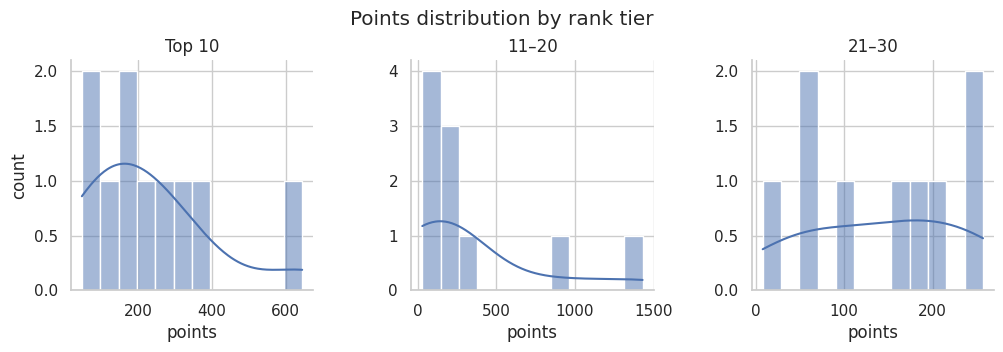

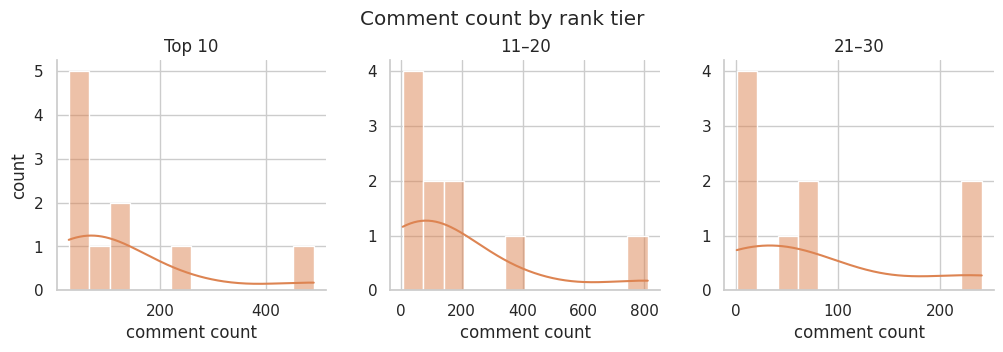

Median points by tier:
 rank_tier
Top 10    179.0
11–20     176.5
21–30     156.0


In [5]:
num_cols = ["rank", "points", "comment_count"]
plot_df = df.dropna(subset=["points", "comment_count"]).copy()

g = sns.FacetGrid(plot_df, col="rank_tier", col_wrap=3, height=3.4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="points", kde=True, bins=12, color="#4C72B0")
g.set_titles("{col_name}")
g.set_axis_labels("points", "count")
g.fig.suptitle("Points distribution by rank tier", y=1.03)
plt.show()

g2 = sns.FacetGrid(plot_df, col="rank_tier", col_wrap=3, height=3.4, sharex=False, sharey=False)
g2.map_dataframe(sns.histplot, x="comment_count", kde=True, bins=12, color="#DD8452")
g2.set_titles("{col_name}")
g2.set_axis_labels("comment count", "count")
g2.fig.suptitle("Comment count by rank tier", y=1.03)
plt.show()

print(
    "Median points by tier:\n",
    plot_df.groupby("rank_tier", observed=True)["points"].median().to_string(),
)


**Univariate readout:** Each snapshot lists 30 distinct outbound domains (no repeats in this scrape). Submitters are mostly unique; only a couple of accounts appear twice. Points and comments are right-skewed overall. Median points in the bottom third of the page exceed the top third — newer stories rank higher before they accumulate score.


## 2 — Multivariate patterns

Relate engagement metrics to rank and content source: correlation among numerics, domain × rank-tier mix, and rank–points slope by domain group.


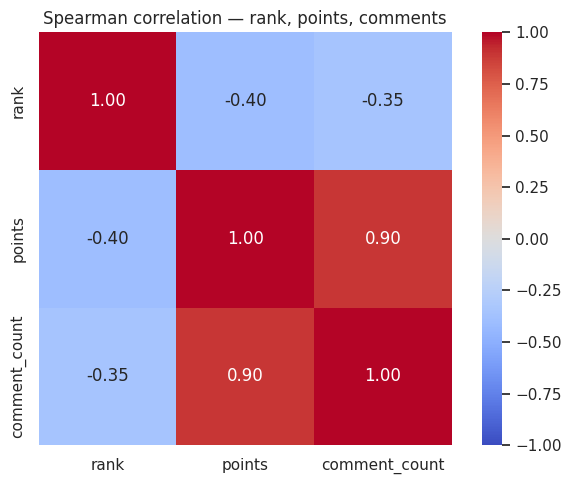

rank vs points: rho=-0.404, p=2.373e-31
points vs comments: rho=0.896, p=6.314e-272


In [6]:
num_df = plot_df[["rank", "points", "comment_count"]].astype(float)
corr = num_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Spearman correlation — rank, points, comments")
plt.tight_layout()
plt.show()

r_rank_points, p_rank_points = stats.spearmanr(plot_df["rank"], plot_df["points"])
r_points_comments, p_points_comments = stats.spearmanr(plot_df["points"], plot_df["comment_count"])
print(f"rank vs points: rho={r_rank_points:.3f}, p={p_rank_points:.4g}")
print(f"points vs comments: rho={r_points_comments:.3f}, p={p_points_comments:.4g}")


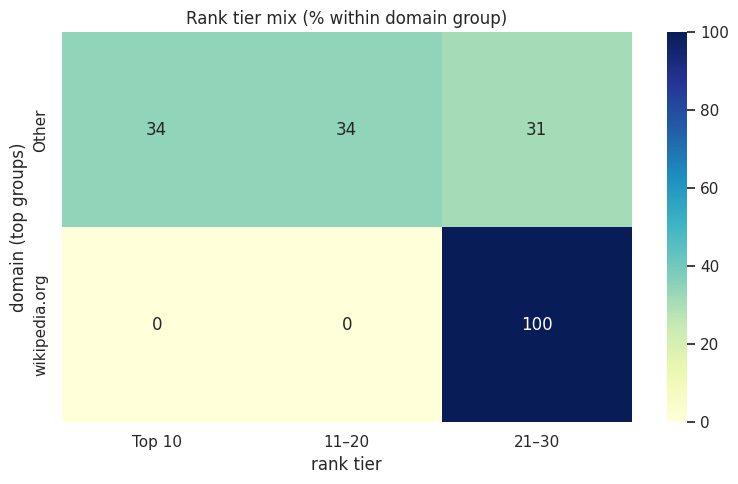

domain_top × rank_tier: chi2=2.069, dof=2, p=0.3554


In [7]:
ct = pd.crosstab(df["domain_top"], df["rank_tier"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct_pct, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
ax.set_title("Rank tier mix (% within domain group)")
ax.set_xlabel("rank tier")
ax.set_ylabel("domain (top groups)")
plt.tight_layout()
plt.show()

chi2, pval, dof, _ = stats.chi2_contingency(ct, correction=False)
print(f"domain_top × rank_tier: chi2={chi2:.3f}, dof={dof}, p={pval:.4g}")


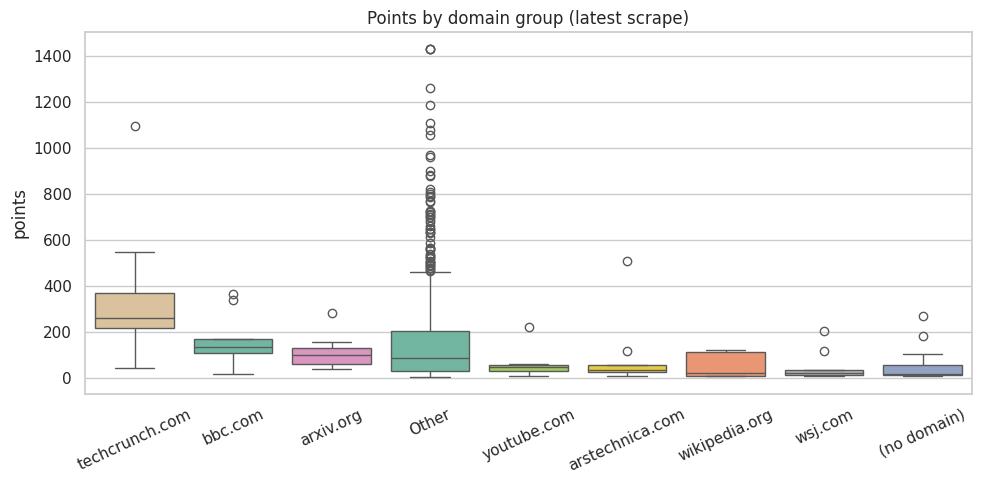

In [8]:
domain_order = (
    plot_df.groupby("domain_top")["points"].median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=plot_df,
    x="domain_top",
    y="points",
    order=domain_order,
    hue="domain_top",
    palette="Set2",
    legend=False,
    ax=ax,
)
ax.set_title("Points by domain group (latest scrape)")
ax.set_xlabel("")
ax.set_ylabel("points")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


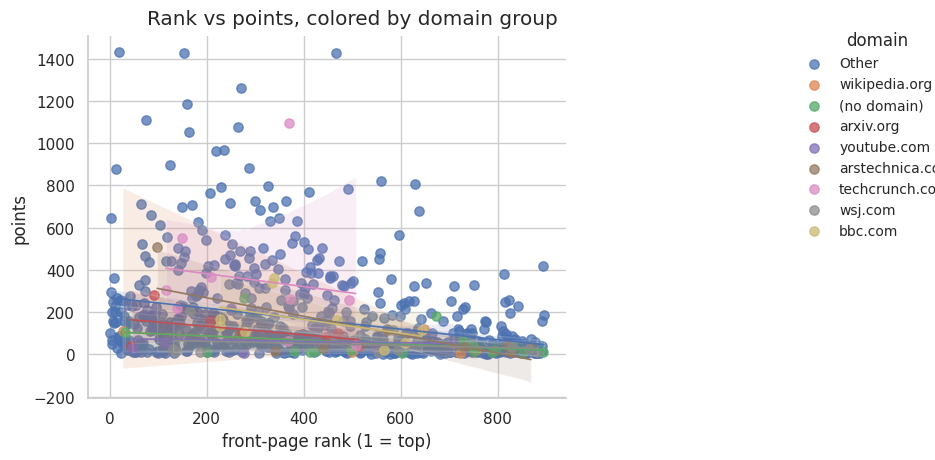

In [9]:
g_lm = sns.lmplot(
    data=plot_df,
    x="rank",
    y="points",
    hue="domain_top",
    height=4.5,
    aspect=1.35,
    scatter_kws={"alpha": 0.75, "s": 45},
    line_kws={"linewidth": 1.2},
)
g_lm.set_axis_labels("front-page rank (1 = top)", "points")
g_lm.fig.suptitle("Rank vs points, colored by domain group", y=1.02)
g_lm._legend.set_title("domain")
g_lm._legend.set_bbox_to_anchor((1.02, 0.98))
g_lm._legend.set_loc("upper left")
plt.show()


## Summary

- **Rank ↔ points (single snapshot):** Rank and points are only weakly related here (often slightly *positive*), because slot #1–#10 are frequently fresh posts with fewer points than older items sliding down the page.
- **Points ↔ comments:** Upvoted stories tend to attract more discussion, though the relationship is noisy — technical deep-dives can score high with fewer comments than controversy-driven posts.
- **Source mix:** One story per domain in this scrape — blogs, GitHub project pages, and news sites share the page evenly rather than one host dominating.
- **Practical use:** For trend monitoring, track snapshot time series (not just this cross-section) to see which domains and submitters repeatedly reach the top decile.
